In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the datasets that include the 'time' and 'perceived_time' variables
df_manual = pd.read_csv('data/manual_with_time.csv')
df_robot = pd.read_csv('data/robot_with_time.csv')

# Assign a setup column to distinguish the two datasets
df_manual['setup'] = 'manual'
df_robot['setup'] = 'robot'

# Combine into a single DataFrame
df_combined = pd.concat([df_manual, df_robot], ignore_index=True)
df_combined

,exp_id,timestamp,operator_id,gender,age,job,job_other,experience,product,task_clarity,...,robot_collision,robot_collision_when,safety_effective,hci_simple,robot_trajectory,system_feedback,comments_system,reduced_robot_downtime,robot_timely,interaction_fluidity
0,lego_1,12/2/2025 19:01:14,1,M,C,Researcher,NaN,None,lego,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,car_2,12/2/2025 19:13:22,2,M,C,Other,AVVOCATO,1_Basic,car,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,lego_3,12/15/2025 18:01:21,3,M,B,Student,NaN,3_Advanced,lego,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,car_4,12/15/2025 22:30:53,4,M,A,Student,NaN,None,car,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,lego_5,12/16/2025 15:51:32,5,M,C,Other,Sviluppatore software in ambito AI,1_Basic,lego,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,car_55,3/19/2026 15:18:18,55,M,A,Student,NaN,1_Basic,car,5,...,Never,NaN,3.0,5.0,5.0,Yes,NaN,"Yes, slightly",5.0,3.0
86,car_56,3/22/2026 23:17:17,56,M,A,Student,NaN,1_Basic,car,5,...,Never,NaN,5.0,5.0,5.0,Yes,NaN,"Yes, slightly",4.0,4.0
87,car_58,3/25/2026 13:22:40,58,M,A,Student,NaN,None,car,5,...,Never,NaN,3.0,4.0,4.0,Yes,NaN,I don't know,3.0,1.0
88,car_59,4/10/2026 14:23:32,59,M,C,Researcher,NaN,1_Basic,car,5,...,Never,NaN,5.0,5.0,5.0,Yes,NaN,"Yes, slightly",5.0,5.0


In [50]:
df_combined.to_csv("data/all_with_time.csv", index=None)

In [51]:
for x in df_combined.columns:
    print(x)

exp_id
timestamp
operator_id
gender
age
job
job_other
experience
product
task_clarity
sequence_intuitive
perceived_difficulty
perceived_time
perceived_difficulty_what
perceived_effort
comfortable
fatigue
fatigue_when
assured
danger
danger_when
efficency
instruments
fluidity
instruments_what
rating
pros
cons
comments_overall
time
setup
robot_facilitated
robot_natural_interaction
robot_obstacle
robot_obstacle_when
robot_safe
robot_velocity
robot_collision
robot_collision_when
safety_effective
hci_simple
robot_trajectory
system_feedback
comments_system
reduced_robot_downtime
robot_timely
interaction_fluidity


## Logging vars
- exp_id
- timestamp
- operator_id
- product

---

## Not interesting columns
- gender. The gender distribution shows a consistent trend across all four configurations. Whether assembling the car or the LEGO, and whether doing it manually or with a robot, the participant pool was heavily skewed toward males, with a smaller proportion of females
- job and job_other. Across all configurations, the trend remains the same: the vast majority of participants were students and university researchers. A handful of "Other" professions (like lawyers or software developers) appeared sporadically, but without any specific bias toward the manual, robotic, LEGO, or car tasks
- comments_overall. Across all configurations, overall comments were highly positive and enthusiastic. Manual Car users frequently used this space to suggest clearer instructions, while robotic users (for both products) consistently suggested implementing audio cues or automatic step approvals to speed up the collaboration
---

## TO INCLUDE (and easy to understand)

- task_clarity. This column shows a unified trend across all four configurations. Participants almost universally rated the clarity of their assigned task with a 4 or 5, indicating that the baseline objective was clear regardless of the product built or the assistance method used

- pros. In the manual configurations, the main positive aspect was the straightforward fun of seeing the final product take shape. In the robot configurations (for both the Car and the LEGO), the universal "pro" was the elimination of cognitive load—users loved that the robot remembered the sequence and handed them the exact piece they needed next
- cons. The manual LEGO setup generated almost no complaints, whereas the manual Car setup cons heavily focused on confusing visual instruction manuals. In contrast, the cons for both the robotic LEGO and robotic Car setups uniformly criticized the robot's latency, slow camera recognition, and the idle waiting time between steps

- MANUAL ONLY
  - sequence_intuitive. This metric was only recorded for the **manual** configurations. The manual LEGO setup was generally perceived as highly intuitive. In contrast, the manual Car setup showed more mixed results, as users frequently felt the provided visual instructions lacked a clear, step-by-step sequence
  - perceived_difficulty. Exclusive to the **manual** setups. The manual LEGO task was almost universally rated as very easy (mostly scoring a 1). The manual Car task, however, diverged significantly, showing much higher difficulty ratings (often 2 to 4) because the car components were more complex to integrate
  - perceived_effort. This **manual**-only column shows the exact same trend across both the LEGO and Car setups. The physical effort required was rated consistently low (mostly 1.0), meaning neither manual assembly task was physically demanding for the participants
  - comfortable. Another **manual**-only metric. Users felt generally comfortable across both the LEGO and Car manual tasks. A few isolated complaints about the workstation being too low appeared equally across both products
  - fatigue and fatigue_when. These **manual** only metrics demonstrate that fatigue was almost non-existent. Nearly all participants in both the manual LEGO and manual Car setups answered "No" to feeling fatigued. Rare exceptions included minor neck strain or issues attaching the car wings
  - assured. Participants in both the manual LEGO and manual Car setups felt highly assured, consistently rating this metric at 4 or 5. The added complexity of the manual Car task did not significantly shake the users' underlying confidence compared to the simple LEGO task
  - efficency. For the **manual** configurations, efficiency ratings were positive overall. The manual Car task occasionally saw slightly lower scores than the manual LEGO task, primarily when users made structural errors and realized they could have used a better sequence
---


## Potentially interesting columns
- age. Age demographics are identically distributed across the four setups, with the majority of participants falling into the younger brackets (students and young adults). However, the conversation history notes that age impacted the configurations differently: older users struggled more in the manual Car setup but felt perfectly safe in the robotic setups, while younger users experienced occasional apprehension of collision specifically in the robot Car setup.
- experience. Self-reported prior experience with assembly and robots was distributed evenly from "None" to "Advanced" across the entire dataset. All four configurations utilized this same balanced pool of participants, ensuring no single setup was skewed by an overly expert or novice group
  
- perceived_time. This column highlights a major divergence between the setups. For the manual LEGO configuration, perceived time was usually rated as "Adequate". Conversely, in the robotic LEGO configuration, the exact same task was frequently perceived as taking "Too long". For the Car configurations, both the manual and robotic setups were frequently rated as taking "Too long," either due to user confusion during manual assembly or robot latency during automated assistance

- rating. General satisfaction shows the exact same trend across all four configurations. Whether assembling the LEGO or the Car, manually or with a robot, participants consistently gave a final holistic rating of 4 or 5 out of 5, indicating high overall engagement with the experiment

- MANUAL ONLY
  - perceived_difficulty_what. Recorded only in **manual** setups. Participants in the manual LEGO task rarely reported major difficulties, occasionally noting minor part identification issues. In stark contrast, nearly all participants in the manual Car setup pointed to specific complex parts—most notably the lateral bumpers ("alettoni laterali"), side skirts, or the engine—as severe pain points
  - instruments and fluidity and instruments_what. These manual metrics evaluated the provided tools and process fluidity. Ratings were high for both the LEGO and Car tasks. However, when asked what could be improved, Car users heavily requested a predefined order of operations or a 3D video, while LEGO users suggested better physical part classification or numbering

- danger and danger_when. In both manual setups, perceived danger was universally negligible. Almost every participant answered "No" to feeling in danger, and left the elaboration column blank or filled it with "Nessuno" (None) [da fondere con un'altra colonna]




- time
- setup
- robot_facilitated
- robot_natural_interaction
- robot_obstacle
- robot_obstacle_when
- robot_safe
- robot_velocity
- robot_collision
- robot_collision_when
- safety_effective
- hci_simple
- robot_trajectory
- system_feedback
- comments_system
- reduced_robot_downtime
- robot_timely
- interaction_fluidity

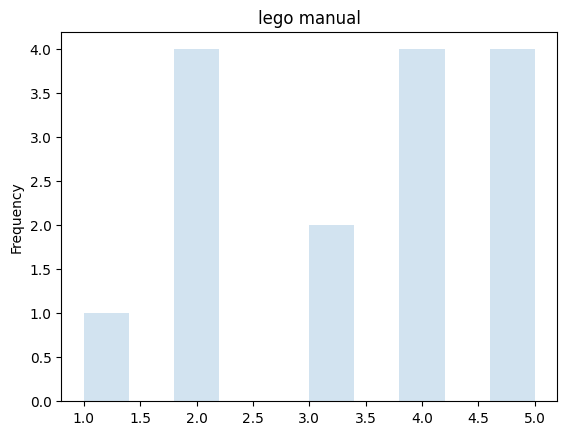

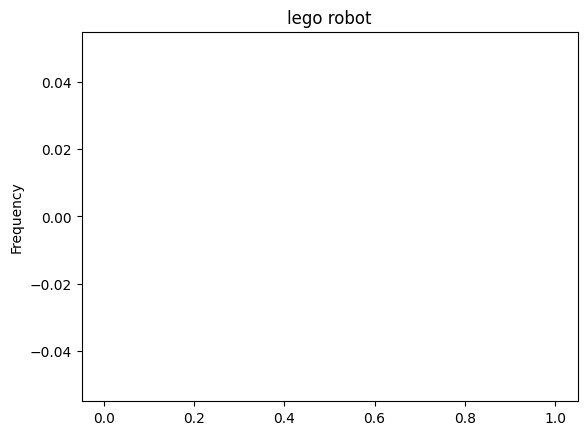

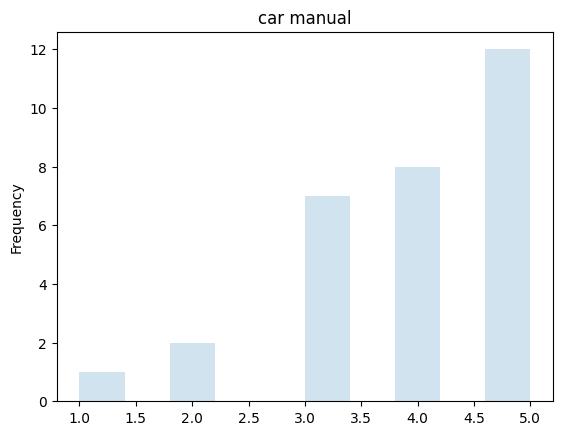

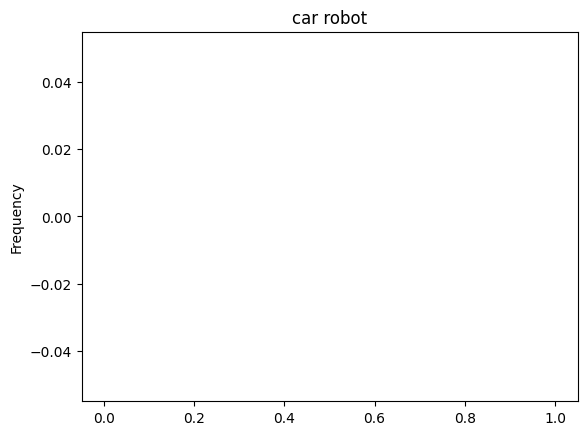

In [62]:
def numericalize_cols(df):
    df["int_gender"] = [0 if x=="M" else 1 for x in df.gender.tolist()]
    df["int_age"] = df.age.replace({"A":0, "B":1, "C":2, "D":3, "E":4})
    df["int_job_stu"] = (df.job == "Student").astype(int)
    df["int_job_eng"] = (df.job == "Engineer").astype(int)
    df["int_job_res"] = (df.job == "Researcher").astype(int)
    df["int_job_oth"] = (df.job == "Other").astype(int)
    df["int_experience"] = df.experience.replace("None", "0_none").apply(lambda x: int(x.split("_")[0]))
    df["int_perceived_time"] = df["perceived_time"].fillna("0_").apply(lambda x: int(x.split("_")[0]))
    df["int_fatigue"] = (df.fatigue == "Yes").astype(int)
    df["int_danger"] = (df.danger == "Yes").astype(int)
    df["int_robot_obstacle"] = (df.robot_obstacle == "Yes").astype(int)
    df["int_robot_velocity"] = df["robot_velocity"].fillna("0_").apply(lambda x: int(x.split("_")[0]))
    df["int_robot_collision"] = (df.robot_collision == "Sometimes").astype(int)
    df["int_system_feedback"] = (df.system_feedback == "Yes").astype(int)
    df["int_reduced_robot_downtime"] = df.reduced_robot_downtime.replace({
        'Yes, slightly':1, 'Yes, significantly':2, "I don't know":0, 'No':0,
    })
    
    return df
numericalize_cols(df_combined)

for PRODUCT in ["lego", "car"]:
    for SETUP in ["manual", "robot"]:
        df = df_combined[(df_combined["product"]==PRODUCT)&(df_combined["setup"]==SETUP)]
        df.comfortable.plot(kind="hist", label=f"{PRODUCT} {SETUP}", alpha=.2)
        plt.title(f"{PRODUCT} {SETUP}")
# plt.legend()
        plt.show()